# Telecom Churn

## 1. Problem defination & Objective Formulation
* This is a Binary classification problem.
* predict  churn with  accuracy atleast above 90%
* Accuracy metrics: confusion matrix, accuracy, recall, precision and f1-score
are used


## 2. Data Collection & Acquisition

* The data is taken in csv format
* It is downloaded from the Kaggle

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('telecom_churn.csv')

## 3. Data Understanding & Initial Exploration

In [2]:
# Schema Understanding
for i in enumerate(data.columns,1):
    print(i)

(1, 'Churn')
(2, 'AccountWeeks')
(3, 'ContractRenewal')
(4, 'DataPlan')
(5, 'DataUsage')
(6, 'CustServCalls')
(7, 'DayMins')
(8, 'DayCalls')
(9, 'MonthlyCharge')
(10, 'OverageFee')
(11, 'RoamMins')


In [3]:
# Data Types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [4]:
data.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


### Units of Measurement for each column

In [5]:
# Churn           ->  bool
# AccountWeeks    -> weeks
# ContractRenewal -> bool
# DataPlan        ->   bool
# DataUsage       -> GB
# CustServCalls   ->  calls count
# DayMins         -> mins
# DayCalls        -> calls  count
# MonthlyCharge   -> rupees
# OverageFee      -> rupees
# RoamMins        -> mins

* Churn(bool) -> whether the customer has left the telecom service
* AccountWeeks()  -> Number of weeks the customer has been with the company
* ContractRenewal(bool)  -> Whether the customer renewed the Contract
* DataPlan(bool) -> Whether the customer has an active data plan
* DataUsage(GB)   ->   Amount of data used during a billing period
* CustServCalls(calls count)  -> Number of calls made to customer service
* DayMins(mins)  -> Total number of minutes used for daytime voice calls
* DayCalls(calls count)  -> Number of daytime voice calls made
* MonthlyCharge(rupees)   -> Total monthly bill amount charged to the customer
* OverageFee(rupees)   -> Extra charges incurred for exceeding plan limits
* RoamMins(mins) -> Minutes used while roaming outside the normal service area


In [6]:
# Number of rows and columns
data.shape

(3333, 11)

In [7]:
# Memory usage -- > 284 KB

In [8]:
# Identifying Nulls
data.isnull().sum()

,0
Churn,0
AccountWeeks,0
ContractRenewal,0
DataPlan,0
DataUsage,0
CustServCalls,0
DayMins,0
DayCalls,0
MonthlyCharge,0
OverageFee,0


In [9]:
# Target variable analysis
data['Churn'].value_counts()   # Class balcnce checking

,count
Churn,
0,2850
1,483


In [10]:
# Data quality checks
data.duplicated().sum()

np.int64(0)

## 4. Exploratory Data Analysis
### Univariate Analysis

In [11]:
data.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


<Axes: xlabel='AccountWeeks', ylabel='Count'>

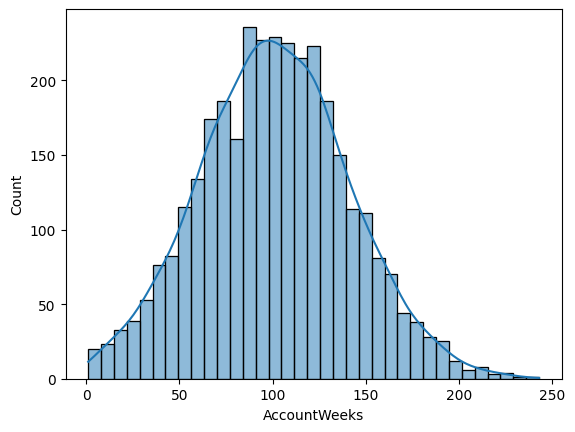

In [12]:
sns.histplot(data=data, x="AccountWeeks", kde=True) # kde stands for kernal densoty estimation


<Axes: xlabel='DataUsage', ylabel='Count'>

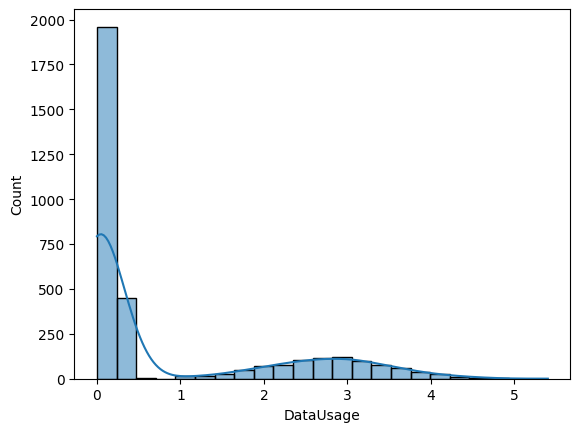

In [13]:
sns.histplot(data=data, x="DataUsage", kde=True)

<Axes: xlabel='DayMins', ylabel='Count'>

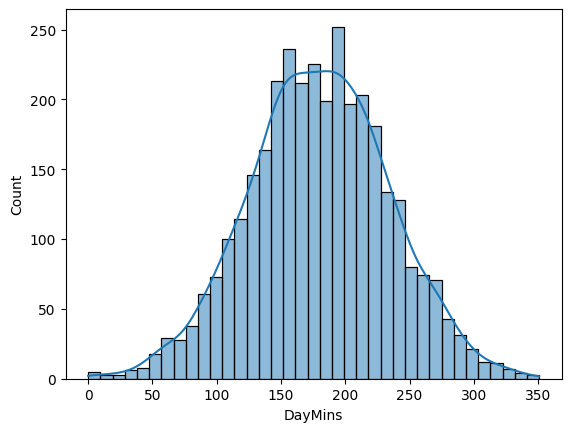

In [14]:
sns.histplot(data=data, x="DayMins", kde=True)

<Axes: xlabel='CustServCalls', ylabel='Count'>

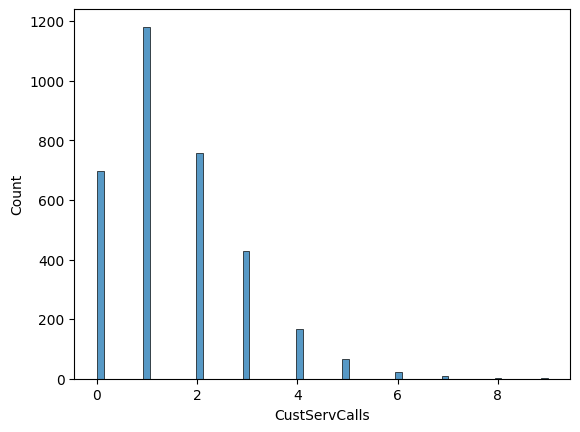

In [15]:
sns.histplot(data['CustServCalls'])

<Axes: xlabel='DayCalls', ylabel='Count'>

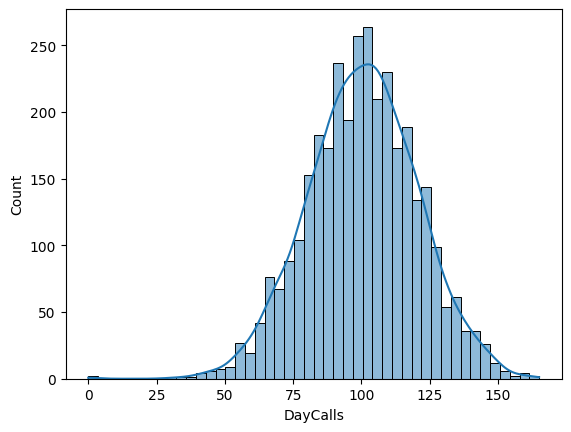

In [16]:
sns.histplot(data=data, x="DayCalls", kde=True)

<Axes: xlabel='MonthlyCharge', ylabel='Count'>

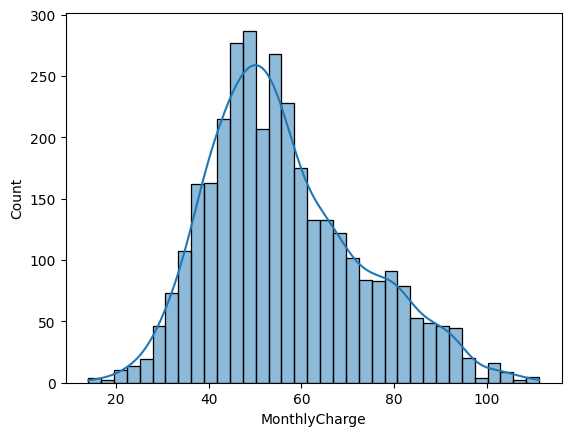

In [17]:
sns.histplot(data=data, x="MonthlyCharge", kde=True)

<Axes: xlabel='OverageFee', ylabel='Count'>

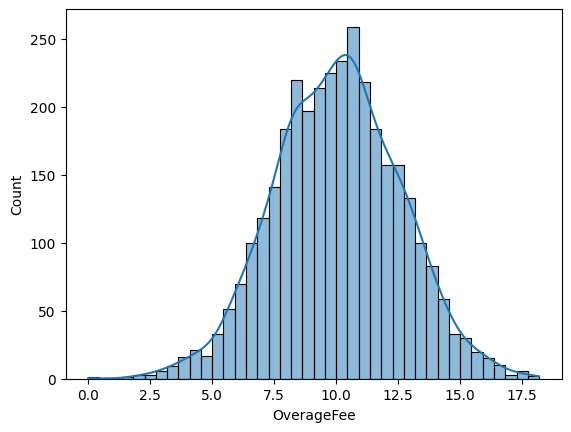

In [18]:
sns.histplot(data=data, x="OverageFee", kde=True)

<Axes: xlabel='RoamMins', ylabel='Count'>

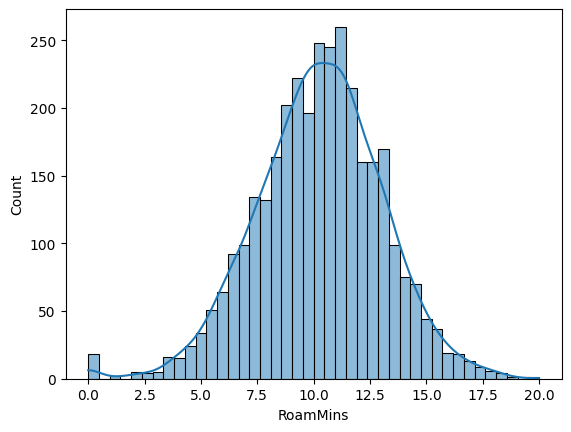

In [19]:
sns.histplot(data=data, x="RoamMins", kde=True)

### Bivariate Analysis

In [20]:
# Feature vs Target

<Axes: xlabel='Churn', ylabel='AccountWeeks'>

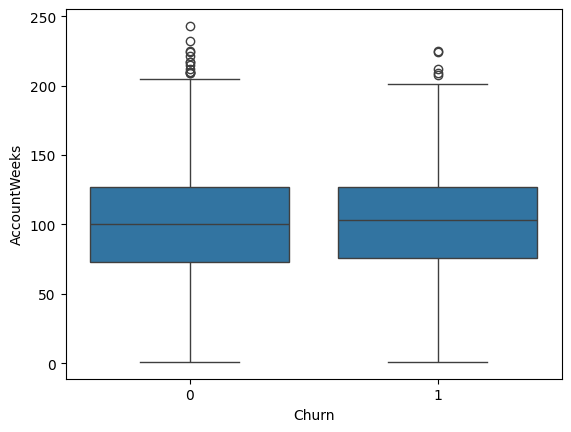

In [21]:
sns.boxplot(x="Churn", y="AccountWeeks", data=data)
# By looking the graph i came to know AccountWeeks alone does not influence much for churn

<Axes: xlabel='MonthlyCharge', ylabel='Count'>

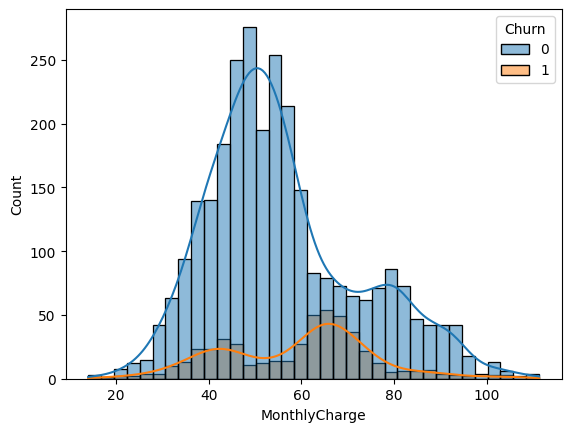

In [22]:
sns.histplot(data=data, x="MonthlyCharge", hue="Churn", kde=True)


<Axes: xlabel='ContractRenewal', ylabel='count'>

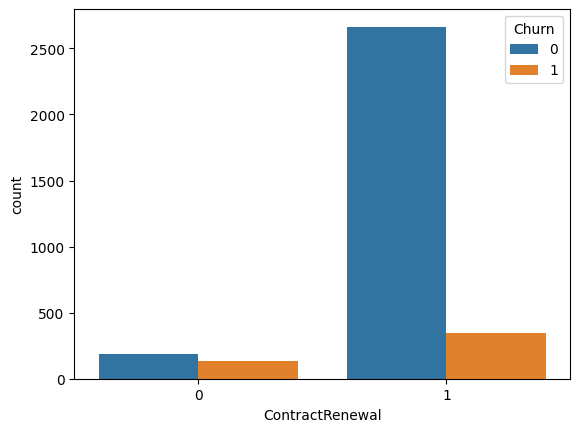

In [23]:
sns.countplot(x="ContractRenewal", hue="Churn", data=data)
# This graphs suggests that the person who is not renewed his contract has high churn risk


<Axes: xlabel='DataUsage', ylabel='MonthlyCharge'>

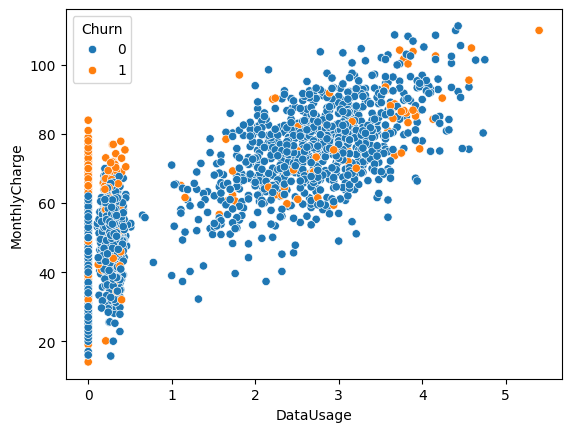

In [24]:
sns.scatterplot(x="DataUsage", y="MonthlyCharge", hue="Churn", data=data)
# some customers are recharging regularly, but not using data is a segment with high churn risk

<Axes: >

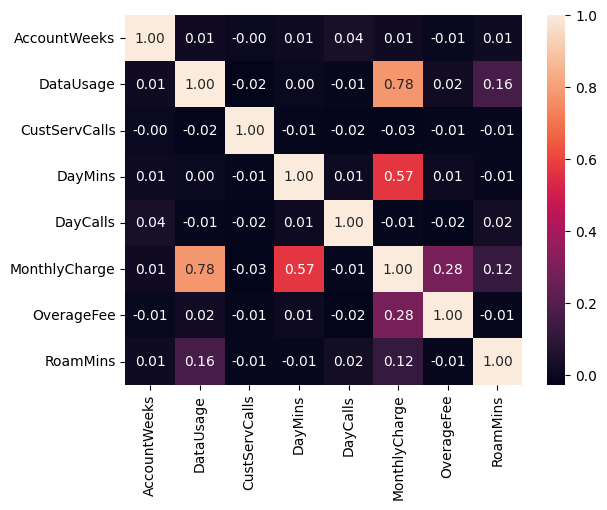

In [25]:

sns.heatmap(data[["AccountWeeks", "DataUsage", "CustServCalls", "DayMins", "DayCalls","MonthlyCharge", "OverageFee","RoamMins"]].corr(),fmt=".2f", annot=True)

In [26]:
data.corr()["Churn"].abs().sort_values(ascending=False)
# Since out of 2 features which has 0.78 correlation(MonthlyCharge & DataUsage) we decide to drop MonthlyCharge because
# the DataUsage feature has high cirrelation compared to MonthlyCharge... (Relation with target variable)


,Churn
Churn,1.000000
ContractRenewal,0.259852
CustServCalls,0.208750
DayMins,0.205151
DataPlan,0.102148
OverageFee,0.092812
DataUsage,0.087195
MonthlyCharge,0.072313
RoamMins,0.068239
DayCalls,0.018459


In [27]:


data = data.drop(['MonthlyCharge'], axis = 1)

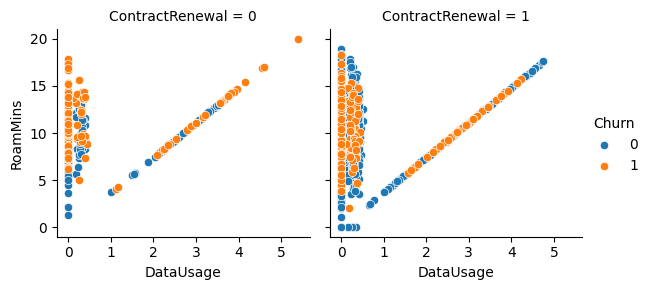

In [28]:
# Multivariate Analysis
sns.FacetGrid(data, col="ContractRenewal", hue="Churn") \
   .map(sns.scatterplot, "DataUsage", "RoamMins") \
   .add_legend()


In [29]:
Q1 = data["DataUsage"].quantile(0.25)
Q3 = data["DataUsage"].quantile(0.75)
IQR = Q3 - Q1

outliers = data[
    (data["DataUsage"] < Q1 - 1.5 * IQR) |
    (data["DataUsage"] > Q3 + 1.5 * IQR)
]
outliers

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,OverageFee,RoamMins
115,1,36,0,1,5.40,0,196.8,89,12.75,20.0
469,0,41,1,1,4.64,2,194.4,63,12.75,17.2
515,0,148,1,1,4.73,1,93.6,137,9.69,17.5
579,0,72,1,1,4.46,1,186.7,108,16.75,16.5
907,0,118,1,1,4.56,1,118.1,83,5.48,16.9
1127,0,159,1,1,4.56,0,184.1,78,9.73,16.9
1467,1,67,0,1,4.56,0,181.1,59,10.80,16.9
1579,0,148,1,1,4.46,2,209.2,110,5.83,16.5
2229,0,83,1,1,4.75,2,191.3,95,12.54,17.6
2687,1,125,0,1,4.59,1,260.8,81,8.19,17.0


In [30]:
Q1 = data["CustServCalls"].quantile(0.25)
Q3 = data["CustServCalls"].quantile(0.75)
IQR = Q3 - Q1

lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR
outliers = data[
    (data["CustServCalls"] < lb) |
    (data["CustServCalls"] > ub)
]
print(lb, ub)

outliers


-0.5 3.5


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,OverageFee,RoamMins
10,1,65,1,0,0.29,4,129.1,137,11.43,12.7
14,0,62,1,0,0.00,4,120.7,70,15.36,13.1
15,1,161,1,0,0.00,4,332.9,67,15.89,5.4
21,1,77,1,0,0.00,5,62.4,89,8.50,5.7
48,1,119,1,0,0.00,5,159.1,114,11.57,8.8
...,...,...,...,...,...,...,...,...,...,...
3307,0,172,1,0,0.00,4,203.9,109,11.70,17.8
3309,0,100,0,0,0.00,4,219.4,112,11.29,12.0
3320,1,122,0,0,0.30,4,140.0,101,9.82,9.7
3322,1,62,1,0,0.00,4,321.1,105,13.28,11.5


<Axes: ylabel='DataUsage'>

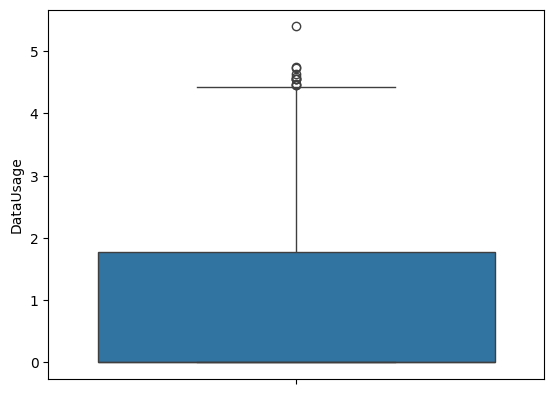

In [31]:
sns.boxplot(data = data['DataUsage'])

<Axes: >

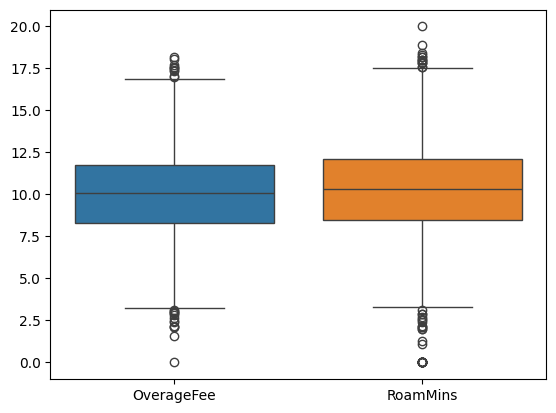

In [32]:
sns.boxplot(data[['OverageFee','RoamMins']])


In [33]:
# By looking at the possible values for each feature there are outliers, but if we find out the relation between other feature they are good outliers
# So we can't replace or remove it

## 5. Data Preprocessing & Preparation

In [34]:
# Missing value treatement
data.isnull().sum().sum()  # There are no null values

np.int64(0)

In [35]:
data['Churn'].value_counts() # Data is imbalanced we need to balance the data

,count
Churn,
0,2850
1,483


In [36]:
    from sklearn.model_selection import train_test_split

In [37]:
x = data.drop('Churn', axis = 1)
y = data['Churn']

In [38]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=89, stratify=y
)


In [39]:
# Feature Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [40]:
x_train_scaled  = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [41]:
# Data is imbalanced so we need to apply SMOTE()
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_train_bal, y_train_bal = smote.fit_resample(x_train_scaled, y_train)

In [42]:
y_train_bal.value_counts() # Data Succesfully balanced

,count
Churn,
0,2137
1,2137


## 6. Model Selection & Algorithm Desgin

### Algorithm identification
* Logistic Regression
* KNN
* Decision Tree
* Random Forest
* Gradient Boosting (XGBOOST, LightGBM)
* SVM
* NaiveBayes

## 7. Model Training

### Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression
modelLR = LogisticRegression(
    C=0.5,
    class_weight="balanced",
    max_iter=1000
)


modelLR.fit(x_train_bal, y_train_bal)

y_pred = modelLR.predict(x_test_scaled)

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.78      0.97      0.86       575
           1       0.83      0.39      0.53       259

    accuracy                           0.79       834
   macro avg       0.81      0.68      0.70       834
weighted avg       0.80      0.79      0.76       834



## K Nearest Neigbours

In [45]:
from sklearn.neighbors import KNeighborsClassifier

modelKNN = KNeighborsClassifier(n_neighbors=5)
modelKNN.fit(x_train_bal, y_train_bal)
y_pred = modelKNN.predict(x_test_scaled)


In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.96      0.89       611
           1       0.81      0.44      0.57       223

    accuracy                           0.82       834
   macro avg       0.82      0.70      0.73       834
weighted avg       0.82      0.82      0.80       834



## Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier
modelDT = DecisionTreeClassifier()
modelDT.fit(x_train_bal, y_train_bal)
y_pred = modelDT.predict(x_test_scaled)

In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       681
           1       0.76      0.60      0.67       153

    accuracy                           0.89       834
   macro avg       0.84      0.78      0.80       834
weighted avg       0.89      0.89      0.89       834



## RandomForest

In [67]:
from sklearn.ensemble import RandomForestClassifier
modelRF = RandomForestClassifier(n_estimators=200, max_depth=20,min_samples_split=6, min_samples_leaf=5, bootstrap=False, class_weight="balanced"


)
modelRF.fit(x_train_bal, y_train_bal)
y_pred_rf = modelRF.predict(x_test_scaled)

In [68]:
from sklearn.metrics import classification_report
print(classification_report(y_pred_rf, y_test))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       702
           1       0.80      0.73      0.77       132

    accuracy                           0.93       834
   macro avg       0.88      0.85      0.86       834
weighted avg       0.93      0.93      0.93       834



## XG Boost

In [51]:
from xgboost import XGBClassifier

modelXGB = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

modelXGB.fit(x_train_bal, y_train_bal)

y_pred = modelXGB.predict(x_test_scaled)


In [52]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       708
           1       0.74      0.71      0.73       126

    accuracy                           0.92       834
   macro avg       0.85      0.84      0.84       834
weighted avg       0.92      0.92      0.92       834



## LightGBM

In [53]:
from lightgbm import LGBMClassifier

modelLGBM = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=100
)

modelLGBM.fit(x_train_bal, y_train_bal)

y_pred_lgbm = modelLGBM.predict(x_test_scaled)


[LightGBM] [Info] Number of positive: 2137, number of negative: 2137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000596 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 4274, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_pred_lgbm, y_test))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       706
           1       0.75      0.71      0.73       128

    accuracy                           0.92       834
   macro avg       0.85      0.83      0.84       834
weighted avg       0.92      0.92      0.92       834



## SupportVectorMachines

In [55]:
from sklearn.svm import SVC

modelSVM = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,   # needed for ROC-AUC
    random_state=42
)

modelSVM.fit(x_train_bal, y_train_bal)

y_pred = modelSVM.predict(x_test_scaled)


In [56]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       622
           1       0.93      0.53      0.67       212

    accuracy                           0.87       834
   macro avg       0.89      0.76      0.80       834
weighted avg       0.88      0.87      0.86       834



## NaiveBayes

In [57]:
from sklearn.naive_bayes import GaussianNB

modelNB = GaussianNB()

modelNB.fit(x_train_scaled, y_train)

y_pred = modelNB.predict(x_test_scaled)


In [58]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       718
           1       0.51      0.53      0.52       116

    accuracy                           0.86       834
   macro avg       0.72      0.73      0.72       834
weighted avg       0.87      0.86      0.87       834



## 8. Model Evaluation & Validation

In [69]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)


[[678  35]
 [ 24  97]]


In [70]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = modelRF.predict_proba(x_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)


ROC-AUC: 0.9415460225099394


## 9. Model Optimization & Finalization

In [72]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}


In [73]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)


In [75]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",        # important for imbalanced data
    cv=5,
    n_jobs=-1,
    verbose=2
)


In [76]:
grid_search.fit(x_train_bal, y_train_bal)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [10, 20, 30, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=2)

In [77]:
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'bootstrap': False, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [78]:
y_pred = best_model.predict(x_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96       713
           1       0.75      0.75      0.75       121

    accuracy                           0.93       834
   macro avg       0.85      0.85      0.85       834
weighted avg       0.93      0.93      0.93       834



In [79]:
import pickle

with open("model_telecom_random_forest.pkl", "wb") as file:
    pickle.dump(best_model, file)
